In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Life Expectancy Data - Life Expectancy Data.csv')

In [3]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.info()
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [5]:
print(df.isnull().sum())

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


In [6]:
df.drop(columns=['Population', 'GDP'], inplace=True)

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [10]:
cat_cols = df.select_dtypes(include=['str']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
print(f"Size after dropping columns: {df.shape}")

Size after dropping columns: (2938, 20)


In [12]:
df.drop_duplicates(inplace=True)
print(f"Size after removing duplicates: {df.shape}")

Size after removing duplicates: (2938, 20)


In [13]:
for col in num_cols:
    if col != 'Year':
        df[col] = (df[col] - df[col].mean()) / df[col].std()

In [14]:
for col in cat_cols:
    df[col] = df[col].astype('category').cat.codes

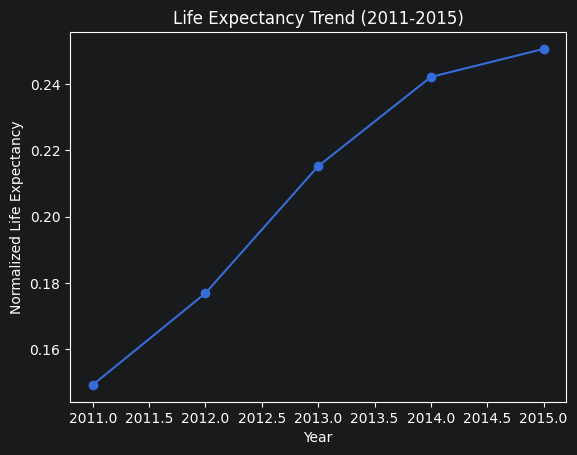

In [15]:
le_trend = df[df['Year'].isin([2011, 2012, 2013, 2014, 2015])]
le_trend.groupby('Year')['Life expectancy'].mean().plot(kind='line', marker='o')
plt.title('Life Expectancy Trend (2011-2015)')
plt.ylabel('Normalized Life Expectancy')
plt.show()

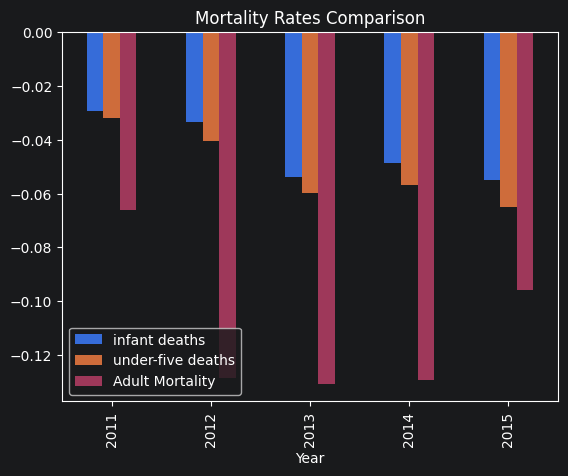

In [16]:
# mortality_vars = ['infant deaths', 'under-five deaths', 'Adult Mortality']
# df_grouped = df[df['Year'].isin([2011, 2012, 2013, 2014, 2015])].groupby('Year')[mortality_vars].mean()
# df_grouped.plot(kind='bar')
# plt.title('Mortality Rates Comparison')
# plt.show()



# mortality_vars = ['infant deaths', 'under-five deaths', 'Adult Mortality']

# # Filter for years 2011-2015 [cite: 29]
# # Note: Ensure 'under-five deaths ' has the trailing space if required by the CSV
# df_subset = df[df['Year'].isin([2011, 2012, 2013, 2014, 2015])]

# # Group by year and calculate mean of actual raw values [cite: 30]
# df_grouped = df_subset.groupby('Year')[mortality_vars].mean()

# # Plotting
# df_grouped.plot(kind='bar', figsize=(10, 6))
# plt.title('Mortality Rates Comparison (Actual Values)')
# plt.ylabel('Average Deaths')
# plt.xlabel('Year')
# plt.legend(title='Category')
# plt.show()


mortality_vars = ['infant deaths', 'under-five deaths', 'Adult Mortality']
df_grouped = df[df['Year'].isin([2011, 2012, 2013, 2014, 2015])].groupby('Year')[mortality_vars].mean()
df_grouped.plot(kind='bar')
plt.title('Mortality Rates Comparison')
plt.show()

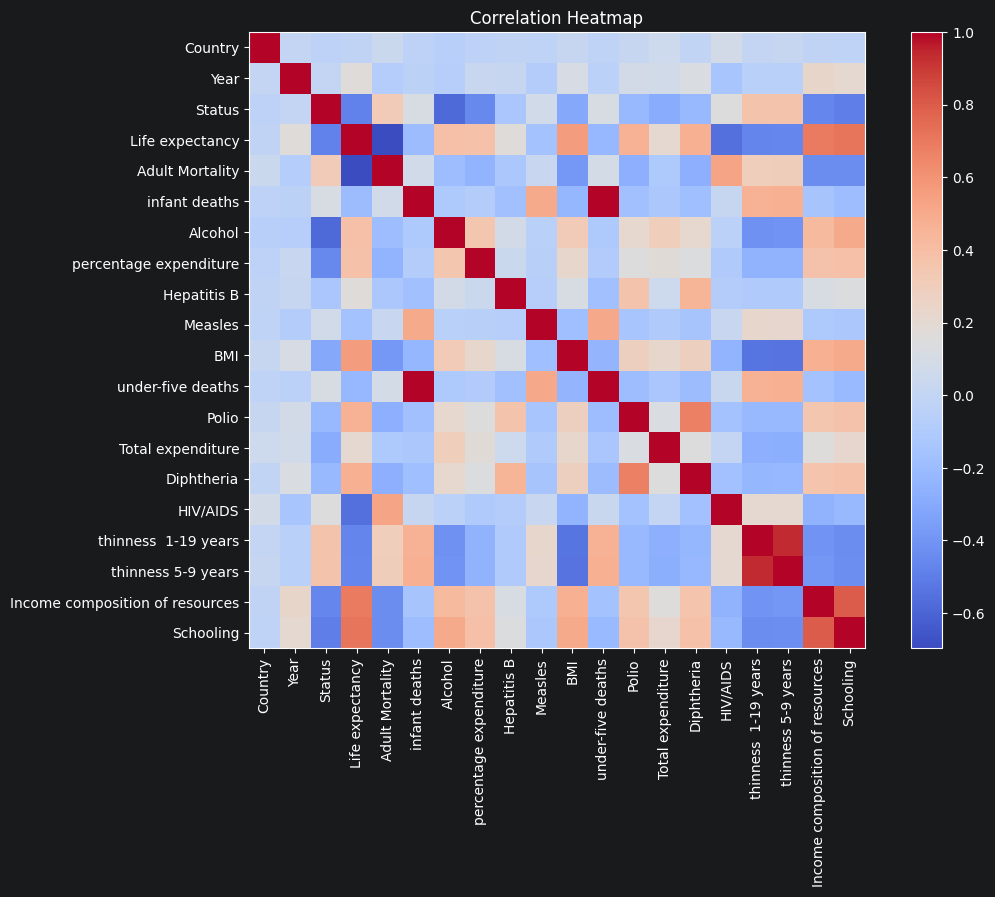

In [17]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)
plt.title('Correlation Heatmap')
plt.show()

In [21]:
corrs = corr_matrix['Life expectancy'].abs().sort_values()
least_corr_features = corrs.index[:3].tolist()
print(f"Dropping least correlated features: {least_corr_features}")
df.drop(columns=least_corr_features, inplace=True)

Dropping least correlated features: ['Country', 'Measles', 'Hepatitis B']


In [22]:
df.to_csv('cleaned.csv', index=False)

In [30]:
data = {
    'Age': ['25', '30', '35', '40', '45'],
    'Income': ['$1000.5', '$1500.0', '$2000.75', '?', '$3000.25'],
    'Signup_Date': ['2023-01-15', '2023-02-20', '2023-03-25', '2023-04-30', '2023-05-05'],
    'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue'],
    'Score': [85, 90, 78, 92, 88]
}

df_sample = pd.DataFrame(data)

print(df_sample.dtypes)

Age            object
Income         object
Signup_Date    object
Color          object
Score           int64
dtype: object


In [31]:
df_sample['Age'] = df_sample['Age'].astype(int)

df_sample['Income'] = df_sample['Income'].replace('?', np.nan)
df_sample['Income'] = df_sample['Income'].str.replace('$', '', regex=False).astype(float)
df_sample['Income'] = df_sample['Income'].fillna(df_sample['Income'].median())
df_sample['Signup_Date'] = pd.to_datetime(df_sample['Signup_Date'])

df_sample['Color'] = df_sample['Color'].astype('category')

In [32]:
df_sample.dtypes

,0
Age,int64
Income,float64
Signup_Date,datetime64[ns]
Color,category
Score,int64
